Ahmad Masood Assignment 2

In [ ]:
pip install gensim nltk


In [ ]:
pip install scikit-learn matplotlib

Part 1


In [ ]:

import gensim.downloader as api
import string
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

dataset = api.load("text8")          # returns a list of word-lists (sentences)
sentences = list(dataset)            # convert to plain list

stop_words = set(stopwords.words('english'))

def preprocess(sentence):
    # Already tokenized; just lowercase, remove punctuation & stopwords
    tokens = [
        word.lower()
        for word in sentence
        if word.isalpha()                  # remove punctuation/numbers
        and word.lower() not in stop_words # remove stopwords
    ]
    return tokens

processed_sentences = [preprocess(s) for s in sentences]

all_tokens = [token for sentence in processed_sentences for token in sentence]
vocabulary  = set(all_tokens)

print(f"\n Total Tokens  : {len(all_tokens):,}")
print(f" Vocabulary Size: {len(vocabulary):,}")

assert len(all_tokens)  >= 10000, "Need at least 10,000 tokens"
assert len(vocabulary)  >= 1000,  "Need vocabulary ≥ 1000"


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



 Total Tokens  : 10,890,638
 Vocabulary Size: 253,702


Part 2

In [ ]:
from gensim.models import Word2Vec

cbow_model = Word2Vec(
    sentences   = processed_sentences,
    vector_size = 50,
    window      = 5,
    min_count   = 2,
    epochs      = 10,
    sg          = 0
)
print(" CBOW model trained")

skipgram_model = Word2Vec(
    sentences   = processed_sentences,
    vector_size = 50,
    window      = 5,
    min_count   = 2,
    epochs      = 10,
    sg          = 1
)
print(" Skip-Gram model trained")

test_words = ["science", "human", "data"]



for word in test_words:
    print("\n Word: '{word}'")

    # CBOW results
    try:
        cbow_similar = cbow_model.wv.most_similar(word, topn=5)
        print(f"   CBOW      : {[w for w, _ in cbow_similar]}")
    except KeyError:
        print(f"   CBOW      : '{word}' not in vocabulary")

    # Skip-Gram results
    try:
        sg_similar = skipgram_model.wv.most_similar(word, topn=5)
        print(f"   Skip-Gram : {[w for w, _ in sg_similar]}")
    except KeyError:
        print(f"   Skip-Gram : '{word}' not in vocabulary")

# ── 2.4 Save Both Models ──────────────────────────────────────────────────────
cbow_model.save("cbow_model.model")
skipgram_model.save("skipgram_model.model")


print(" Both models saved:")


 CBOW model trained
 Skip-Gram model trained

 Word: '{word}'
   CBOW      : ['psychology', 'zooarchaeology', 'anthropology', 'icsu', 'scientific']
   Skip-Gram : ['fiction', 'nanoscience', 'populariser', 'multidisciplinary', 'psychohistory']

 Word: '{word}'
   CBOW      : ['humans', 'animal', 'sentient', 'alien', 'natural']
   Skip-Gram : ['animal', 'nonhuman', 'epms', 'instinctual', 'humans']

 Word: '{word}'
   CBOW      : ['storing', 'indexes', 'queries', 'redundancy', 'input']
   Skip-Gram : ['printout', 'storing', 'terabytes', 'dbms', 'dataset']
 Both models saved:


# Model Comparison

1. CBOW clusters words more tightly together since it averages context signals.

2. Skip-Gram spreads words more across the plot, capturing finer relationships.

3. Both models group similar topic words together but Skip-Gram shows
   clearer separation between different word categories.

Part 3

✅ Top 50 words selected


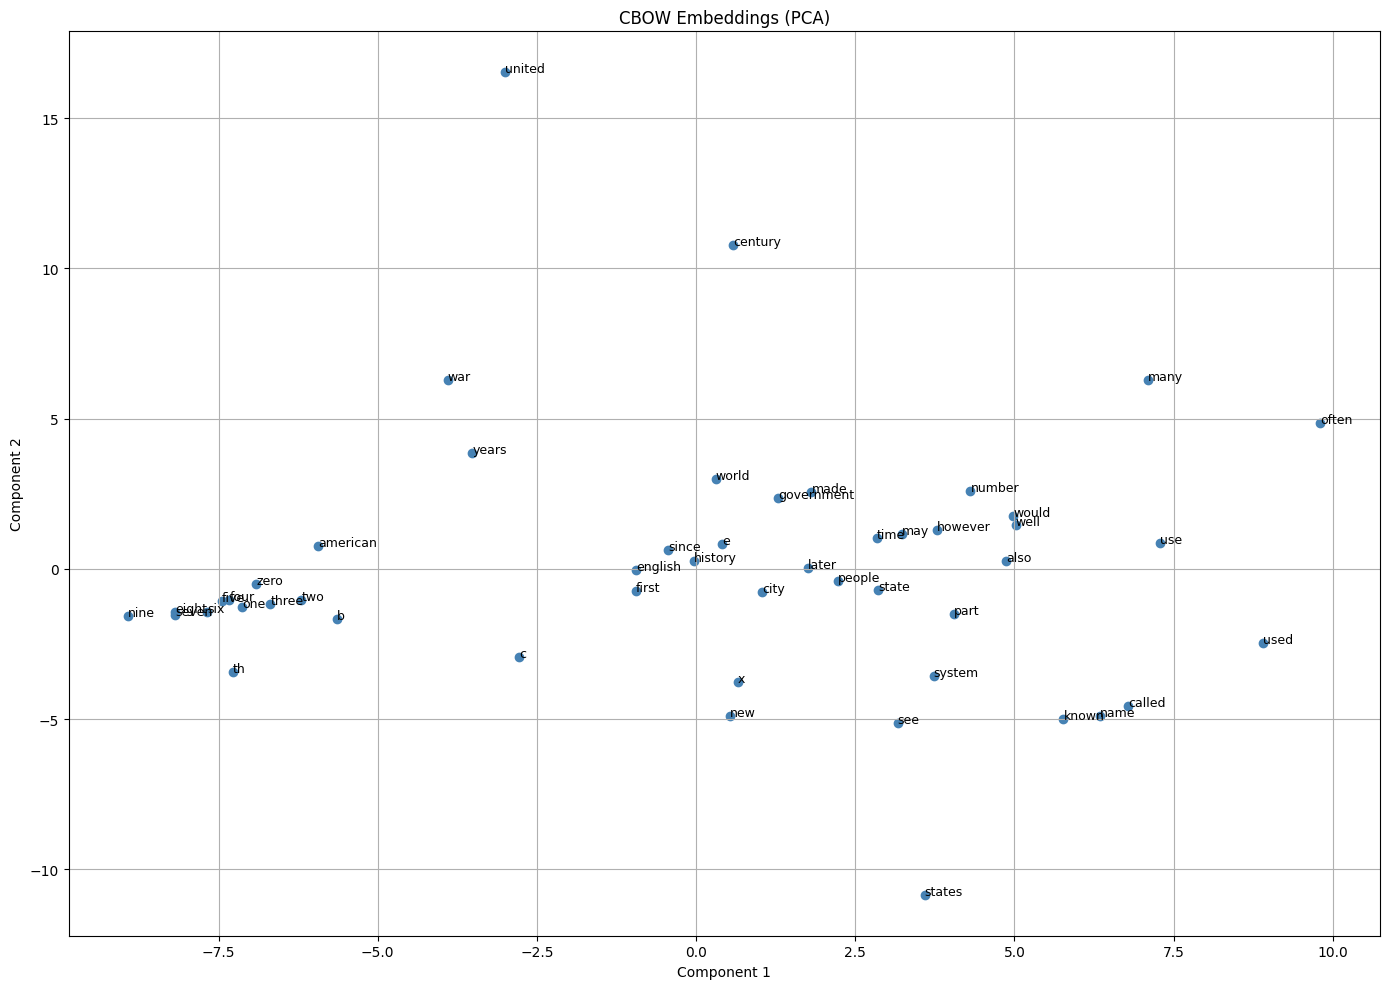

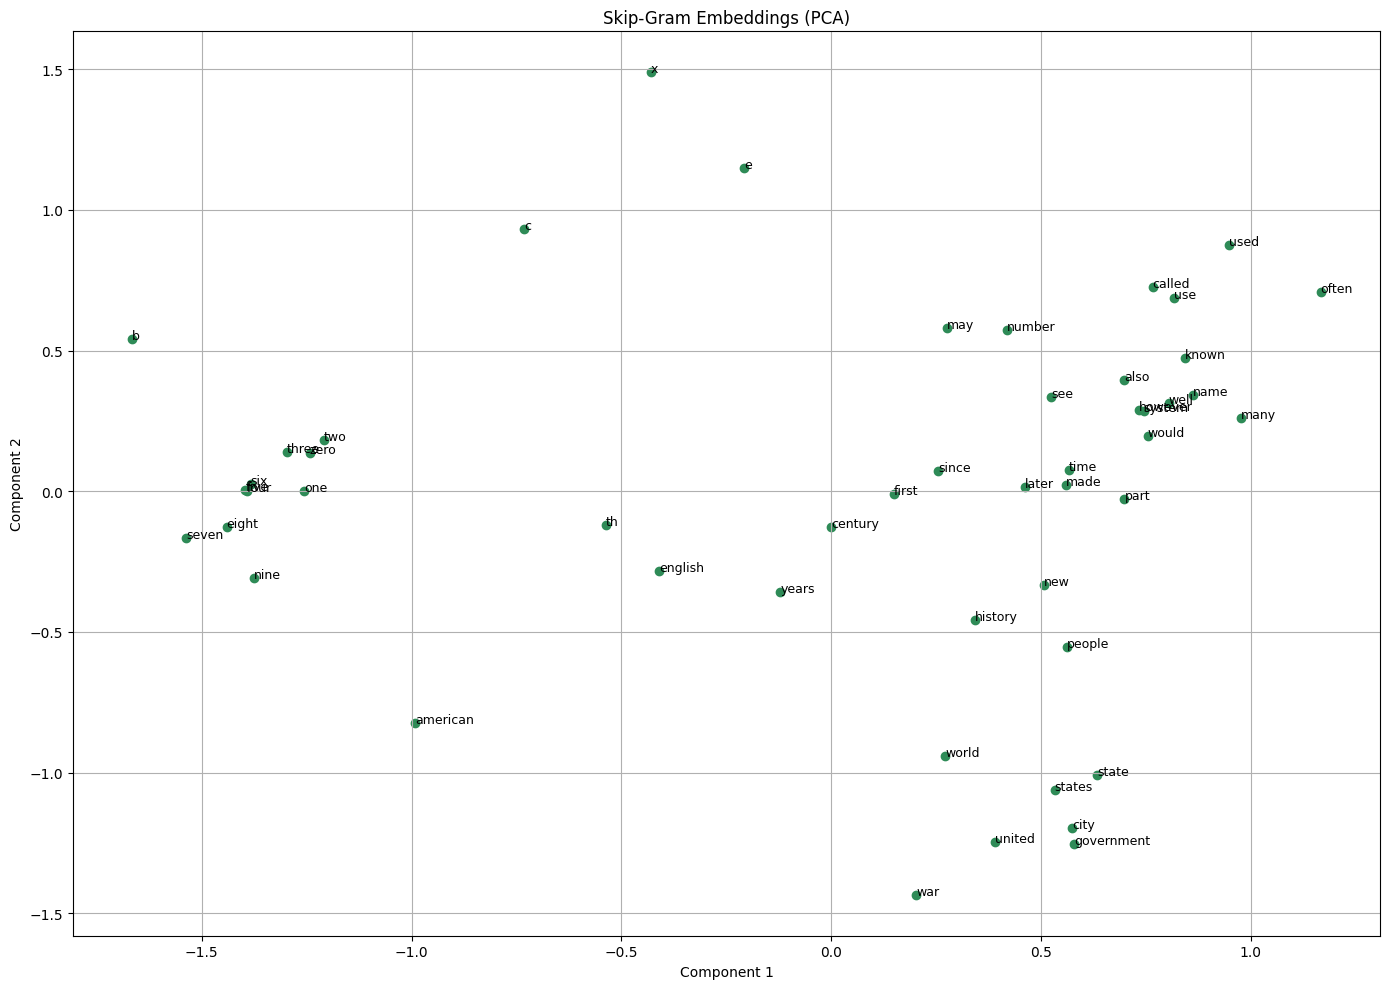

✅ Step 3 complete


In [ ]:
# ─── Step 3: Embedding Visualization ─────────────────────────────────────────

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ── 3.1 Get Top 50 Most Frequent Words ───────────────────────────────────────
top_50_words = cbow_model.wv.index_to_key[:50]  # already sorted by frequency
print(f"✅ Top 50 words selected")

# ── 3.2 Extract Vectors ───────────────────────────────────────────────────────
cbow_vectors    = [cbow_model.wv[word]     for word in top_50_words]
skip_vectors    = [skipgram_model.wv[word] for word in top_50_words]

# ── 3.3 Reduce to 2D with PCA ────────────────────────────────────────────────
pca      = PCA(n_components=2, random_state=42)
cbow_2d  = pca.fit_transform(cbow_vectors)
skip_2d  = pca.fit_transform(skip_vectors)

# ── 3.4 Plot CBOW ─────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 10))
plt.scatter(cbow_2d[:, 0], cbow_2d[:, 1], color="steelblue")
for i, word in enumerate(top_50_words):
    plt.annotate(word, (cbow_2d[i, 0], cbow_2d[i, 1]), fontsize=9)
plt.title("CBOW Embeddings (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

# ── 3.5 Plot Skip-Gram ────────────────────────────────────────────────────────
plt.figure(figsize=(14, 10))
plt.scatter(skip_2d[:, 0], skip_2d[:, 1], color="seagreen")
for i, word in enumerate(top_50_words):
    plt.annotate(word, (skip_2d[i, 0], skip_2d[i, 1]), fontsize=9)
plt.title("Skip-Gram Embeddings (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

print("✅ Step 3 complete")

Part 4

Preparing corpus...
✅ Dictionary size : 253,702 words
✅ Corpus size     : 1,701 documents

Training LDA model...
✅ LDA model trained

           TOP KEYWORDS PER TOPIC

📌 Topic 1: ['one', 'zero', 'two', 'nine', 'three', 'five', 'eight', 'four', 'also', 'six']

📌 Topic 2: ['one', 'nine', 'zero', 'two', 'eight', 'three', 'five', 'seven', 'four', 'six']

📌 Topic 3: ['one', 'zero', 'nine', 'two', 'three', 'eight', 'five', 'six', 'four', 'seven']

📌 Topic 4: ['one', 'nine', 'zero', 'two', 'eight', 'five', 'four', 'three', 'seven', 'six']

📌 Topic 5: ['one', 'zero', 'nine', 'two', 'five', 'eight', 'three', 'four', 'six', 'seven']


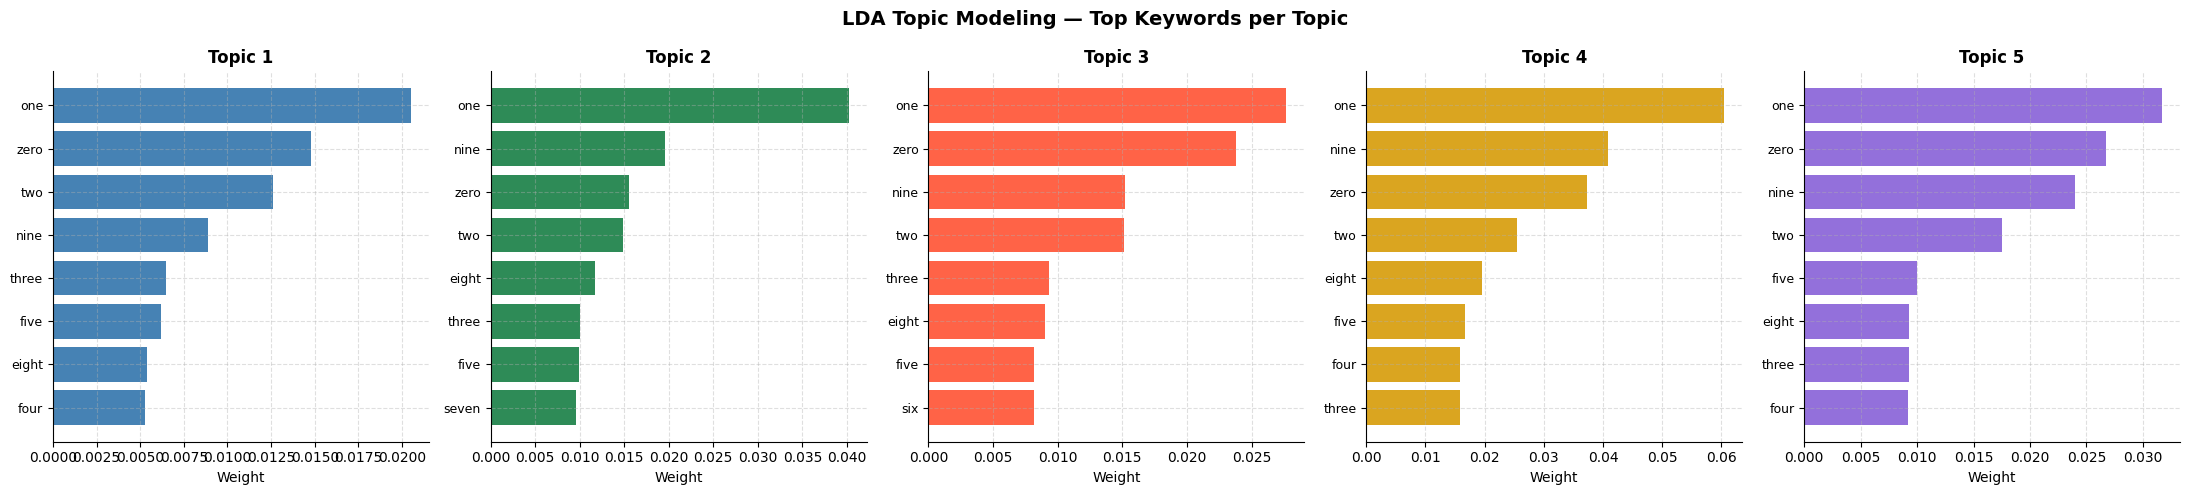

✅ Bar chart saved as 'lda_topics.png'


In [ ]:

from gensim import corpora
from gensim.models import LdaModel
import matplotlib.pyplot as plt

dictionary = corpora.Dictionary(processed_sentences)
bow_corpus  = [dictionary.doc2bow(sentence) for sentence in processed_sentences]
print(f" Dictionary size : {len(dictionary):,} words")
print(f" Corpus size     : {len(bow_corpus):,} documents")

lda_model = LdaModel(
    corpus     = bow_corpus,
    id2word    = dictionary,
    num_topics = 5,
    random_state = 42,
    passes     = 10,
    alpha      = 'auto'
)
print(" LDA model trained")

for i in range(5):
    words = lda_model.show_topic(i, topn=10)
    print(f"\n📌 Topic {i+1}: {[w for w, _ in words]}")
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("LDA Topic Modeling — Top Keywords per Topic",
             fontsize=14, fontweight='bold')

colors = ["steelblue", "seagreen", "tomato", "goldenrod", "mediumpurple"]

for i, ax in enumerate(axes):
    words  = lda_model.show_topic(i, topn=8)
    labels = [w for w, _ in words]
    scores = [round(s, 4) for _, s in words]

    ax.barh(labels[::-1], scores[::-1], color=colors[i])
    ax.set_title(f"Topic {i+1}", fontweight='bold')
    ax.set_xlabel("Weight")
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("lda_topics.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Bar chart saved as 'lda_topics.png'")